### Business Problem
Users find it difficult to choose restaurants from thousands of available options.
The goal is to build a recommendation system that suggests restaurants based on user preferences like cuisine, city, price range, and ratings using content-based filtering.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df = pd.read_csv('Dataset.csv')

In [3]:
pd.set_option('display.max_columns', None)

df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,80,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,9.051128e+06,8.791521e+06,53.000000,301962.500000,6.004089e+06,1.835229e+07,1.850065e+07
Country Code,9551.0,1.836562e+01,5.675055e+01,1.000000,1.000000,1.000000e+00,1.000000e+00,2.160000e+02
Longitude,9551.0,6.412657e+01,4.146706e+01,-157.948486,77.081343,7.719196e+01,7.728201e+01,1.748321e+02
Latitude,9551.0,2.585438e+01,1.100794e+01,-41.330428,28.478713,2.857047e+01,2.864276e+01,5.597698e+01
Average Cost for two,9551.0,1.199211e+03,1.612118e+04,0.000000,250.000000,4.000000e+02,7.000000e+02,8.000000e+05
Price range,9551.0,1.804837e+00,9.056088e-01,1.000000,1.000000,2.000000e+00,2.000000e+00,4.000000e+00
Aggregate rating,9551.0,2.666370e+00,1.516378e+00,0.000000,2.500000,3.200000e+00,3.700000e+00,4.900000e+00
Votes,9551.0,1.569097e+02,4.301691e+02,0.000000,5.000000,3.100000e+01,1.310000e+02,1.093400e+04


##### Handle Missing Values

In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Cuisines,9


In [7]:
df['Cuisines'].value_counts()

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,354
Fast Food,354
"North Indian, Mughlai",334
...,...
"World Cuisine, Patisserie, Cafe",1
"Burger, Izgara",1
"Desserts, B�_rek",1


In [8]:
df['Cuisines'] = df['Cuisines'].fillna(df['Cuisines'].mode()[0])

In [9]:
df.duplicated().sum()

np.int64(0)

##### Drop Irrelevant Columns

In [10]:
df = df.drop(columns=['Restaurant ID', 'Country Code', 'Longitude', 'Latitude','Switch to order menu'], axis=1)

In [11]:
categorical_cols = df.select_dtypes(
    exclude=['int64', 'float64']
).columns

for col in categorical_cols:
  if(df[col].nunique() < 10):
    print(df[col].value_counts())
    print("-" * 50)

Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64
--------------------------------------------------
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64
--------------------------------------------------
Is delivering now
No     9517
Yes      34
Name: count, dtype: int64
--------------------------------------------------
Rating color
Orange        3737
White         2148
Yellow        2100
Green         1079
Dark Green     301
Red            186
Name: count, dtype: int64
--------------------------------------------------
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64
--------------------------------------------------


##### Encoding Categorical Variables

In [12]:
binary_cols = [
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now'
]

for col in binary_cols:
    df[col] = df[col].map({
        'No': 0,
        'Yes': 1
    })

In [13]:
rating_color_map = {
    'White': 0,
    'Red': 1,
    'Orange': 2,
    'Yellow': 3,
    'Green': 4,
    'Dark Green': 5
}

df['Rating color'] = df['Rating color'].map(rating_color_map)

In [14]:
rating_text_map = {
    'Not rated': 0,
    'Poor': 1,
    'Average': 2,
    'Good': 3,
    'Very Good': 4,
    'Excellent': 5
}

df['Rating text'] = df['Rating text'].map(rating_text_map)

In [15]:
df['Address'].nunique()

8918

In [16]:
df = df.drop(columns=['Address'], axis=1)

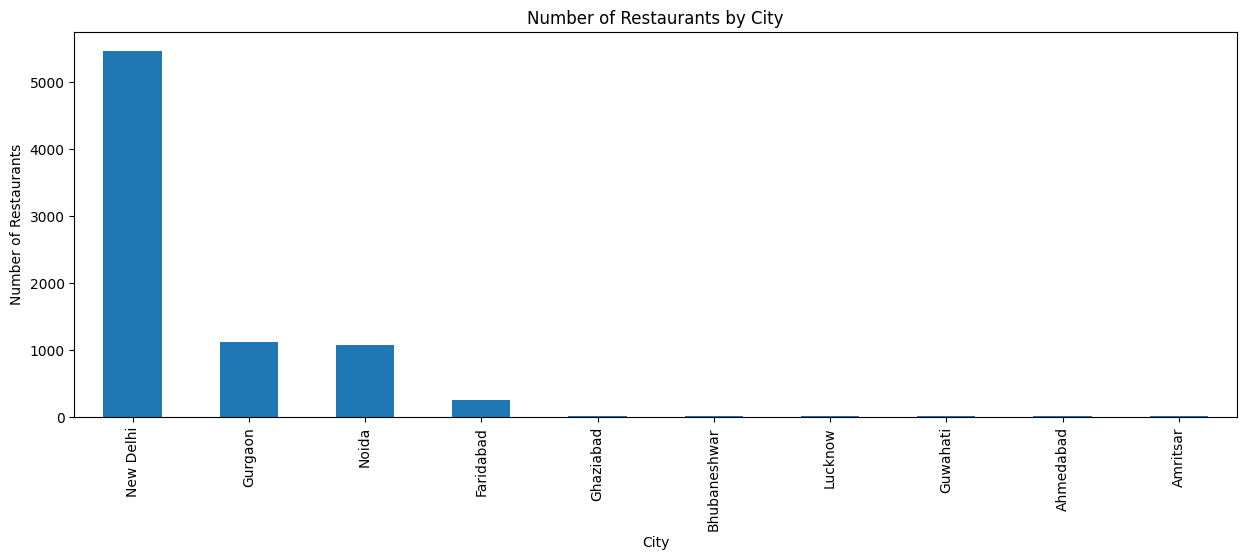

In [17]:
city_restaurant = df.groupby('City')['Restaurant Name'].count().sort_values(ascending=False)

city_restaurant.head(10).plot(kind='bar', figsize=(15, 5), title='Number of Restaurants by City')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.show()

##### Observation

The dataset is highly imbalanced with respect to cities. Most restaurants are concentrated in a few cities such as New Delhi, Gurgaon, and Noida, while many cities contain very few restaurants. This imbalance may affect recommendation quality for smaller cities due to insufficient data.

In [18]:
scaler_cost   = StandardScaler()
scaler_price  = StandardScaler()
scaler_rating = StandardScaler()
scaler_votes  = StandardScaler()

df['Average Cost for two'] = scaler_cost.fit_transform(df[['Average Cost for two']])
df['Price range']          = scaler_price.fit_transform(df[['Price range']])
df['Aggregate rating']     = scaler_rating.fit_transform(df[['Aggregate rating']])
df['Votes']                = scaler_votes.fit_transform(df[['Votes']])

In [19]:
all_cuisines = []

for cuisine in df['Cuisines']:
  cuisine_list = cuisine.split(',')

  for item in cuisine_list:
    all_cuisines.append(item.strip())

In [20]:
cuisine_count = Counter(all_cuisines)
cuisine_count

Counter({'French': 29,
         'Japanese': 135,
         'Desserts': 653,
         'Seafood': 174,
         'Asian': 233,
         'Filipino': 10,
         'Indian': 70,
         'Sushi': 75,
         'Korean': 21,
         'Chinese': 2735,
         'European': 148,
         'Mexican': 181,
         'American': 390,
         'Ice Cream': 226,
         'Cafe': 703,
         'Italian': 764,
         'Pizza': 381,
         'Bakery': 745,
         'Mediterranean': 112,
         'Fast Food': 1986,
         'Brazilian': 28,
         'Arabian': 28,
         'Bar Food': 39,
         'Grill': 21,
         'International': 21,
         'Peruvian': 1,
         'Latin American': 11,
         'Burger': 251,
         'Juices': 29,
         'Healthy Food': 150,
         'Beverages': 229,
         'Lebanese': 69,
         'Sandwich': 53,
         'Steak': 62,
         'BBQ': 33,
         'Gourmet Fast Food': 1,
         'Mineira': 1,
         'North Eastern': 9,
         'North Indian': 3969,
       

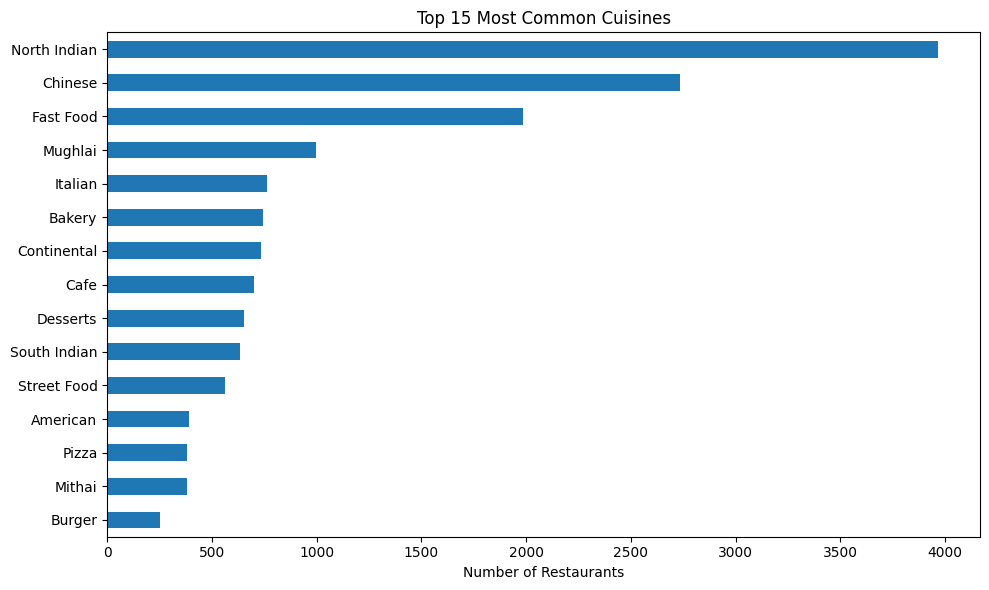

In [21]:
top_cuisines_series = pd.Series(dict(Counter(all_cuisines).most_common(15)))
top_cuisines_series.sort_values().plot(kind='barh', figsize=(10, 6),
                                        title='Top 15 Most Common Cuisines')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.show()

In [22]:
df['Cuisines'] = df['Cuisines'].str.split(', ')

In [23]:
mlb = MultiLabelBinarizer()

cuisine_encoded = pd.DataFrame(
    mlb.fit_transform(df['Cuisines']),
    columns=mlb.classes_,
    index=df.index
)

In [24]:
df = pd.concat([df, cuisine_encoded], axis=1)

In [25]:
cuisine_encoded.sum().sort_values(
    ascending=False
).head(10)

,0
North Indian,3969
Chinese,2733
Fast Food,1986
Mughlai,994
Italian,764
Bakery,744
Continental,736
Cafe,703
Desserts,653
South Indian,636


##### Observations

* The 'Cuisines' column contains multiple cuisine values in a single row separated by commas.
* Cuisine type is one of the most important features influencing restaurant recommendations.
* Many restaurants offer multiple cuisines such as:
'
Japanese, Chinese,
North Indian
'

* The column could not be directly used by the model because it was stored as text.
* Therefore, the cuisines were split into separate values and transformed into numerical features using 'MultiLabelBinarizer'.
* This conversion helped the recommendation system understand which cuisines are available in each restaurant.
* Popular cuisines appeared frequently across restaurants, making cuisine information highly useful for generating recommendations based on user preferences.


In [26]:
df = df.drop(columns=['Cuisines'], axis=1)

In [27]:
df['Locality'].nunique()

1208

In [28]:
df['Locality'].value_counts().head(20)

,count
Locality,
Connaught Place,122
Rajouri Garden,99
Shahdara,87
Defence Colony,86
Malviya Nagar,85
Pitampura,85
Mayur Vihar Phase 1,84
Rajinder Nagar,81
Safdarjung,80


In [29]:
df['Currency'].value_counts()

,count
Currency,
Indian Rupees(Rs.),8652
Dollar($),482
Pounds(��),80
Brazilian Real(R$),60
Rand(R),60
Emirati Diram(AED),60
NewZealand($),40
Turkish Lira(TL),34
Botswana Pula(P),22


##### Observation

The 'Currency' column mainly represents country specific monetary units and does not directly influence restaurant similarity or user preferences. Since the dataset is heavily dominated by one country and currency type, this feature provides limited value for the recommendation system and can be removed.

In [30]:
df = df.drop(columns=['Currency'], axis=1)

In [31]:
df.select_dtypes(include=['object']).columns

Index(['Restaurant Name', 'City', 'Locality', 'Locality Verbose'], dtype='object')

In [32]:
tfidf = TfidfVectorizer()

location_vectors = tfidf.fit_transform(df['Locality Verbose'])

In [33]:
df = df.drop(columns=['City', 'Locality', 'Locality Verbose'], axis=1)

In [34]:
restaurant_names = df['Restaurant Name']
df = df.drop(columns=['Restaurant Name'], axis=1)

In [35]:
final_features = hstack([df.values, location_vectors])

In [36]:
similarity_matrix = cosine_similarity(final_features)

In [37]:
def convert_user_input(locality_verbose, average_cost, has_table_booking, has_online_delivery,
                       is_delivering_now, price_range, aggregate_rating, rating_color, rating_text, votes, cuisines):

    binary_map = {'No': 0, 'Yes': 1}
    locality_verbose_vector = tfidf.transform([locality_verbose])
    user_input = pd.DataFrame([{
        'Average Cost for two': scaler_cost.transform([[average_cost]])[0][0],
        'Has Table booking':    binary_map.get(has_table_booking, 0),
        'Has Online delivery':  binary_map.get(has_online_delivery, 0),
        'Is delivering now':    binary_map.get(is_delivering_now, 0),
        'Price range':          scaler_price.transform([[price_range]])[0][0],
        'Aggregate rating':     scaler_rating.transform([[aggregate_rating]])[0][0],
        'Rating color':         rating_color_map.get(rating_color, 0),
        'Rating text':          rating_text_map.get(rating_text, 0),
        'Votes':                scaler_votes.transform([[votes]])[0][0],
    }])

    cuisine_vector = mlb.transform([cuisines])

    user_input_df = hstack([user_input, cuisine_vector, locality_verbose_vector])

    return user_input_df

In [38]:
def recommend_restaurants(locality_verbose, average_cost, has_table_booking, has_online_delivery, is_delivering_now,
                          price_range, aggregate_rating, rating_color, rating_text, votes, cuisines):

    user_input_df = convert_user_input(locality_verbose, average_cost, has_table_booking, has_online_delivery,
                                       is_delivering_now, price_range, aggregate_rating, rating_color, rating_text, votes, cuisines)
    scores = cosine_similarity(user_input_df, final_features).flatten()
    top_indices = scores.argsort()[-10:][::-1]

    return pd.DataFrame({
        'Restaurant Name': restaurant_names[top_indices],
        'Similarity Score': scores[top_indices]
    })

In [39]:
recommend_restaurants(
    'Century City Mall, Poblacion, Makati City',
    1100, 'Yes', 'No', 'No', 3, 4.5, 'Dark Green', 'Excellent', 314, ['French', 'Japanese', 'Desserts']
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Restaurant Name,Similarity Score
0,Le Petit Souffle,0.998934
1,Izakaya Kikufuji,0.970292
4,Sambo Kojin,0.951022
17,Balay Dako,0.950925
9,Locavore,0.948526
1145,La Plage,0.947820
9396,Bone Daddies,0.947370
9299,Milse,0.947331
9384,Restaurant Gordon Ramsay,0.947265
9383,Roka,0.947198


In [40]:
recommend_restaurants(
    'BGC Stopover Pavillion, Bonifacio Global City, Taguig City',
    600, 'No', 'No', 'No', 2, 4.5, 'Dark Green', 'Excellent', 118, ['Cafe', 'Korean', 'Desserts']
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Restaurant Name,Similarity Score
18,Hobing Korean Dessert Cafe,1.000000
9520,Turta Home Cafe,0.966932
2281,The Basement Caf��,0.963377
2315,Churrolto,0.961523
9332,Midnight Espresso,0.960832
9233,Freshco - The Health Caf��,0.958040
9232,Coffee Culture,0.957894
290,The Belle General,0.957628
8100,Starbucks,0.957521
7082,Drool Waffles,0.957254


In [41]:
recommend_restaurants(
    'UP Town Center, Diliman, Quezon City',
    800, 'No', 'No', 'No',
    3, 4.8, 'Dark Green', 'Excellent', 294,
    ['Filipino', 'Mexican']
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Restaurant Name,Similarity Score
12,Silantro Fil-Mex,0.998999
17,Balay Dako,0.965767
9,Locavore,0.963771
9489,Perron,0.960512
10,Silantro Fil-Mex,0.957630
245,Los Agaves,0.956350
9321,The Hangar,0.956045
9343,Bodega,0.955442
2378,Nawras Seafood Restaurant,0.955384
9358,La Favorita,0.955086
